In [31]:
import pandas as pd
import importlib
import process_utils as pu
importlib.reload(pu)

<module 'process_utils' from '/home/sam/Downloads/gh/TSCIL-AL/result/process_utils.py'>

In [32]:
# Create dictionary with dataframes for each dataset
tscil_results = {}

# UCI-HAR
tscil_results['HAR'] = pd.DataFrame({
    'Method': ['CIL-ER', 'CIL-ASER'],
    'Avg End Acc': [72.8, 89.1],
    'Avg End Acc error': [19.7, 6.1],
    'Avg End Fgt': [22.1, 13.2],
    'Avg End Fgt error': [37.2, 11.4],
    'Avg Cur Acc': [87.2, 97.8],
    'Avg Cur Acc error': [10.4, 1.9]
})

# UWave
tscil_results['UWAVE'] = pd.DataFrame({
    'Method': ['CIL-ER', 'CIL-ASER'],
    'Avg End Acc': [72.7, 83.2],
    'Avg End Acc error': [2.7, 3.5],
    'Avg End Fgt': [33.6, 20.3],
    'Avg End Fgt error': [3.4, 4.5],
    'Avg Cur Acc': [97.9, 98.4],
    'Avg Cur Acc error': [0.5, 0.4]
})

# DSA
tscil_results['DSA'] = pd.DataFrame({
    'Method': ['CIL-ER', 'CIL-ASER'],
    'Avg End Acc': [79.6, 96.9],
    'Avg End Acc error': [15.6, 2.2],
    'Avg End Fgt': [23.6, 3.7],
    'Avg End Fgt error': [19.2, 2.7],
    'Avg Cur Acc': [89.9, 100.0],
    'Avg Cur Acc error': [9.6, 0.1]
})

# GRABMyo
tscil_results['GRABMYO'] = pd.DataFrame({
    'Method': ['CIL-ER', 'CIL-ASER'],
    'Avg End Acc': [46.5, 55.9],
    'Avg End Acc error': [3.2, 5.1],
    'Avg End Fgt': [35.0, 49.4],
    'Avg End Fgt error': [5.7, 5.0],
    'Avg Cur Acc': [73.7, 95.4],
    'Avg Cur Acc error': [4.7, 1.3]
})

# WISDM
tscil_results['WISDM'] = pd.DataFrame({
    'Method': ['CIL-ER', 'CIL-ASER'],
    'Avg End Acc': [41.7, 51.6],
    'Avg End Acc error': [5.0, 13.7],
    'Avg End Fgt': [27.9, 53.1],
    'Avg End Fgt error': [12.4, 14.3],
    'Avg Cur Acc': [60.7, 95.8],
    'Avg Cur Acc error': [10.2, 2.0]
})

In [33]:
AL_SETUP = {
    'HAR': (3,300),
    'UWAVE' : (3,25),
    'GRABMYO': (6,20),
    'WISDM': (5,40)
}

In [34]:
DATASET = 'WISDM'

AL_TOTAL = AL_SETUP[DATASET][0]
AL_BUDGET = AL_SETUP[DATASET][1]

In [ ]:
filtered_files = pu.get_filtered_files([DATASET], [AL_TOTAL])
print("Filtered Files:\t", filtered_files)
pu.generate_score_files(filtered_files)

show_filter = ['uncertainty-margin', 'typiclust' ,'coreset', 'random', 'kmeans-ppp', ] # 'typicore', 'coresetprob'
colfilter = ['task', 'cycle', 'index', 
            'Random-ER', 'Random-ASER',
            'Uncertainty-margin-ER', 'Uncertainty-margin-ASER',
            'TypiClust-ER', 'TypiClust-ASER',
            'CoreSet-ER', 'CoreSet-ASER',
            #'CoreSetProb-ER', 'CoreSetProb-ASER',
            'Kmeans-ppp-ASER', 'Kmeans-ppp-ER',
            #'TypiCore-ER', 'TypiCore-ASER'
            ]

filtered_files = [f for f in filtered_files if not 'TypiClustScore-' in f]


Filtered Files:	 ['wisdm/CoreSet_ER_cycle_5_per_40_wisdm.csv', 'wisdm/Uncertainty-entropy_ER_cycle_5_per_40_wisdm.csv', 'wisdm/CoreSetProb_ASER_cycle_5_per_40_wisdm.csv', 'wisdm/Uncertainty-lc_ER_cycle_5_per_40_wisdm.csv', 'wisdm/TypiClustLimit_ER_cycle_5_per_40_wisdm.csv', 'wisdm/TypiClust_ER_cycle_5_per_40_wisdm.csv', 'wisdm/TypiClustScore-var_ER_cycle_5_per_40_wisdm.csv', 'wisdm/Kmeans-ppp_ER_cycle_5_per_40_wisdm.csv', 'wisdm/TypiClustLimit_ASER_cycle_5_per_40_wisdm.csv', 'wisdm/Uncertainty-lc_ASER_cycle_5_per_40_wisdm.csv', 'wisdm/Kmeans-ppp_ASER_cycle_5_per_40_wisdm.csv', 'wisdm/Random_ASER_cycle_5_per_40_wisdm.csv', 'wisdm/TypiClustScore-invvar_ER_cycle_5_per_40_wisdm.csv', 'wisdm/Random_ER_cycle_5_per_40_wisdm.csv', 'wisdm/Uncertainty-entropy_ASER_cycle_5_per_40_wisdm.csv', 'wisdm/TypiCore_ASER_cycle_5_per_40_wisdm.csv', 'wisdm/CoreSet_ASER_cycle_5_per_40_wisdm.csv', 'wisdm/TypiCore_ER_cycle_5_per_40_wisdm.csv', 'wisdm/TypiClustScore-norm_ER_cycle_5_per_40_wisdm.csv', 'wisdm/Cor

## Diversity and Random

In [36]:
uncert_la = pu.aggregate_al_strategies(f'{DATASET.lower()}_scores', show_filter, AL_TOTAL, AL_BUDGET, 'learning_accuracy')
uncert_la.style.apply(pu.highlight_max, axis=1).format(precision=2)

,task,cycle,index,CoreSet-ASER,TypiCore-ASER,Uncertainty-margin-ASER,TypiClust-ASER,CoreSet-ER,Random-ASER,TypiClustScore-invvar-ER,TypiClustScore-invnorm-ER,Random-ER,TypiClustScore-var-ER,TypiClustLimit-ER,Kmeans-ppp-ASER,TypiClustScore-norm-ER,Kmeans-ppp-ER,CoreSetProb-ER,TypiClustLimit-ASER,TypiClust-ER,Uncertainty-margin-ER,CoreSetProb-ASER,TypiCore-ER
0,0,0,0,52.58,68.09,68.65,68.09,52.58,68.65,63.36,64.13,68.65,62.18,68.50,67.17,62.47,67.17,67.17,68.50,68.09,68.65,67.17,68.09
1,0,1,1,59.83,69.61,69.49,69.61,59.83,68.94,65.68,65.54,68.94,72.20,79.78,76.63,76.49,76.63,76.63,79.78,69.61,69.49,74.16,69.61
2,0,2,2,60.41,71.49,69.25,79.22,60.41,69.96,69.85,74.79,69.96,81.72,82.92,79.88,87.20,79.88,79.88,82.92,79.22,69.25,78.45,71.49
3,0,3,3,70.39,76.56,73.94,87.05,70.39,77.45,70.04,90.80,77.45,83.78,87.82,87.28,89.96,87.28,87.28,87.82,87.05,73.94,90.09,76.56
4,0,4,4,71.54,83.17,77.89,89.30,71.54,78.65,80.93,92.00,78.65,87.62,90.05,87.58,91.10,87.58,87.58,90.05,89.30,77.89,91.64,83.17
5,1,0,5,66.44,80.26,79.65,74.61,59.97,75.42,72.40,68.56,75.22,75.20,67.05,72.57,74.30,64.98,64.98,76.45,68.80,74.47,76.69,75.49
6,1,1,6,84.36,88.02,81.38,88.11,82.54,79.99,88.23,83.11,79.54,86.76,81.99,88.20,86.02,84.28,84.28,85.64,84.88,78.25,86.72,84.56
7,1,2,7,88.79,90.11,83.65,90.35,85.64,82.59,89.94,89.28,83.47,87.85,85.87,90.76,88.32,85.02,85.02,87.76,87.26,83.00,90.52,86.41
8,1,3,8,90.61,90.02,84.51,90.82,88.94,82.42,89.47,91.02,86.38,89.26,87.60,91.79,88.03,91.49,91.49,88.55,89.40,82.38,91.14,89.10
9,1,4,9,91.00,88.50,87.54,89.52,91.27,87.96,89.99,91.52,87.68,89.88,87.81,92.37,88.94,92.64,92.64,87.61,88.88,82.24,92.73,88.24


In [37]:
uncert_la.columns

Index(['task', 'cycle', 'index', 'CoreSet-ASER', 'TypiCore-ASER',
       'Uncertainty-margin-ASER', 'TypiClust-ASER', 'CoreSet-ER',
       'Random-ASER', 'TypiClustScore-invvar-ER', 'TypiClustScore-invnorm-ER',
       'Random-ER', 'TypiClustScore-var-ER', 'TypiClustLimit-ER',
       'Kmeans-ppp-ASER', 'TypiClustScore-norm-ER', 'Kmeans-ppp-ER',
       'CoreSetProb-ER', 'TypiClustLimit-ASER', 'TypiClust-ER',
       'Uncertainty-margin-ER', 'CoreSetProb-ASER', 'TypiCore-ER'],
      dtype='object')

In [38]:
uncert_la = uncert_la[colfilter]
uncert_la

,task,cycle,index,Random-ER,Random-ASER,Uncertainty-margin-ER,Uncertainty-margin-ASER,TypiClust-ER,TypiClust-ASER,CoreSet-ER,CoreSet-ASER,CoreSetProb-ER,CoreSetProb-ASER,Kmeans-ppp-ASER,Kmeans-ppp-ER,TypiCore-ER,TypiCore-ASER
0,0,0,0,68.65,68.65,68.65,68.65,68.09,68.09,52.58,52.58,67.17,67.17,67.17,67.17,68.09,68.09
1,0,1,1,68.94,68.94,69.49,69.49,69.61,69.61,59.83,59.83,76.63,74.16,76.63,76.63,69.61,69.61
2,0,2,2,69.96,69.96,69.25,69.25,79.22,79.22,60.41,60.41,79.88,78.45,79.88,79.88,71.49,71.49
3,0,3,3,77.45,77.45,73.94,73.94,87.05,87.05,70.39,70.39,87.28,90.09,87.28,87.28,76.56,76.56
4,0,4,4,78.65,78.65,77.89,77.89,89.30,89.30,71.54,71.54,87.58,91.64,87.58,87.58,83.17,83.17
5,1,0,5,75.22,75.42,74.47,79.65,68.80,74.61,59.97,66.44,64.98,76.69,72.57,64.98,75.49,80.26
6,1,1,6,79.54,79.99,78.25,81.38,84.88,88.11,82.54,84.36,84.28,86.72,88.20,84.28,84.56,88.02
7,1,2,7,83.47,82.59,83.00,83.65,87.26,90.35,85.64,88.79,85.02,90.52,90.76,85.02,86.41,90.11
8,1,3,8,86.38,82.42,82.38,84.51,89.40,90.82,88.94,90.61,91.49,91.14,91.79,91.49,89.10,90.02
9,1,4,9,87.68,87.96,82.24,87.54,88.88,89.52,91.27,91.00,92.64,92.73,92.37,92.64,88.24,88.50


['Random-ER', 'Random-ASER']


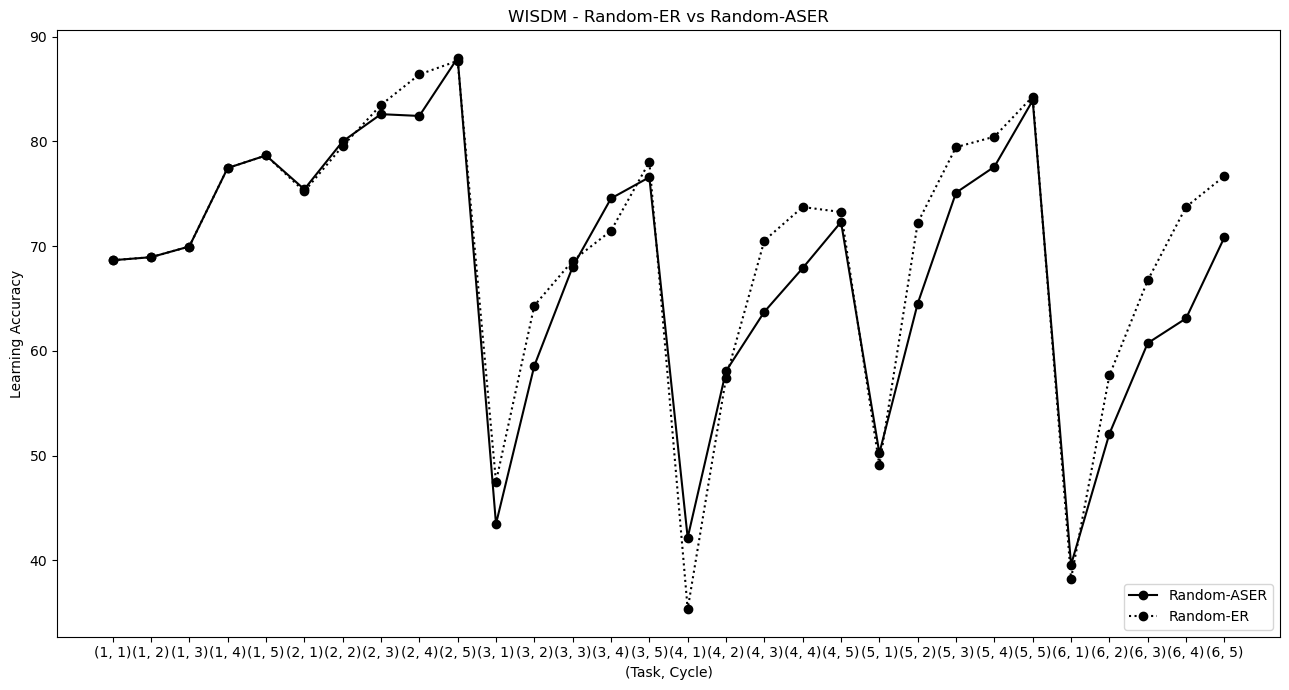

In [39]:
dic = uncert_la[['cycle', 'task', 'Random-ER', 'Random-ASER']]

pu.plot_progress(
    df=dic, 
    loc='lower right',
    title=f"{DATASET} - Random-ER vs Random-ASER",
    X_label="(Task, Cycle)", 
    Y_label="Learning Accuracy")

['Random-ER', 'Random-ASER', 'Uncertainty-margin-ER', 'Uncertainty-margin-ASER', 'TypiClust-ER', 'TypiClust-ASER', 'CoreSet-ER', 'CoreSet-ASER', 'CoreSetProb-ER', 'CoreSetProb-ASER', 'Kmeans-ppp-ASER', 'Kmeans-ppp-ER', 'TypiCore-ER', 'TypiCore-ASER']


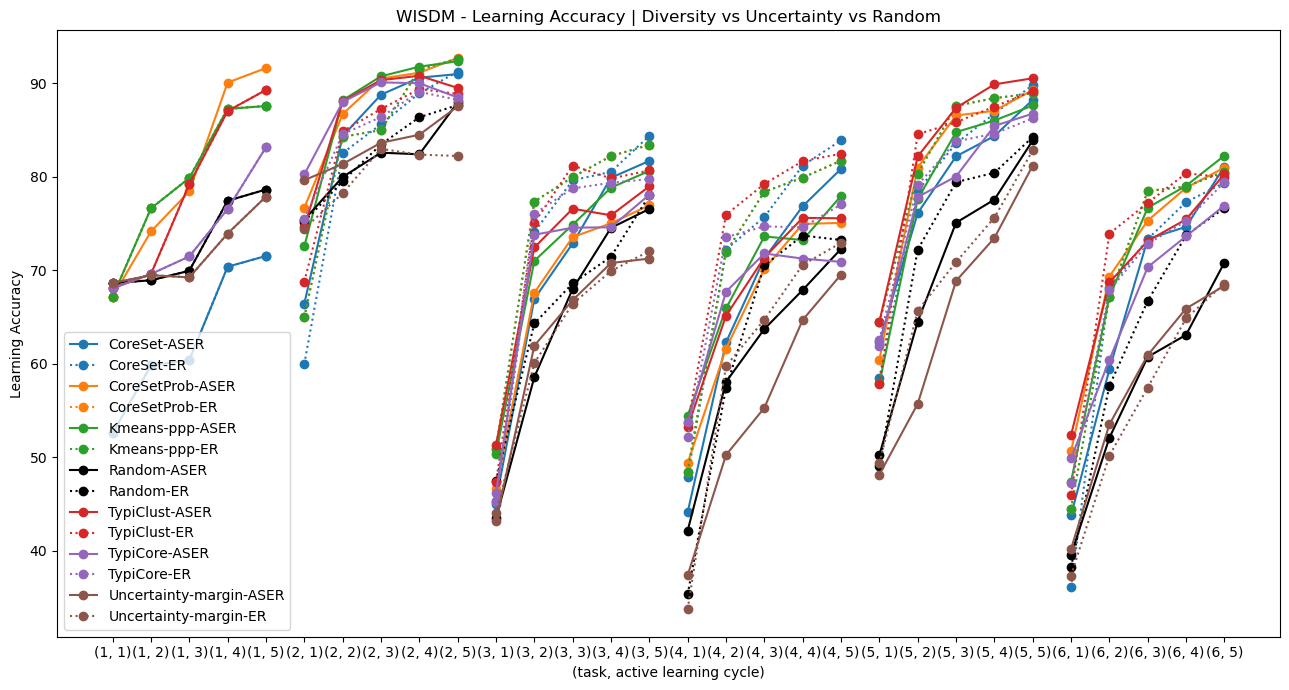

In [40]:
pu.plot_progress(
    df=uncert_la, 
    loc='best',
    title=f"{DATASET} - Learning Accuracy | Diversity vs Uncertainty vs Random",
    X_label="(task, active learning cycle)", 
    Y_label="Learning Accuracy",
    break_between_tasks=True
    )

In [41]:
uncert_aa = pu.aggregate_al_strategies(f'{DATASET.lower()}_scores', show_filter, AL_TOTAL, AL_BUDGET, 'average_accuracy')
uncert_aa.style.apply(pu.highlight_max, axis=1).format(precision=2)
uncert_aa = uncert_aa[colfilter]

['Random-ER', 'Random-ASER', 'Uncertainty-margin-ER', 'Uncertainty-margin-ASER', 'TypiClust-ER', 'TypiClust-ASER', 'CoreSet-ER', 'CoreSet-ASER', 'CoreSetProb-ER', 'CoreSetProb-ASER', 'Kmeans-ppp-ASER', 'Kmeans-ppp-ER', 'TypiCore-ER', 'TypiCore-ASER']


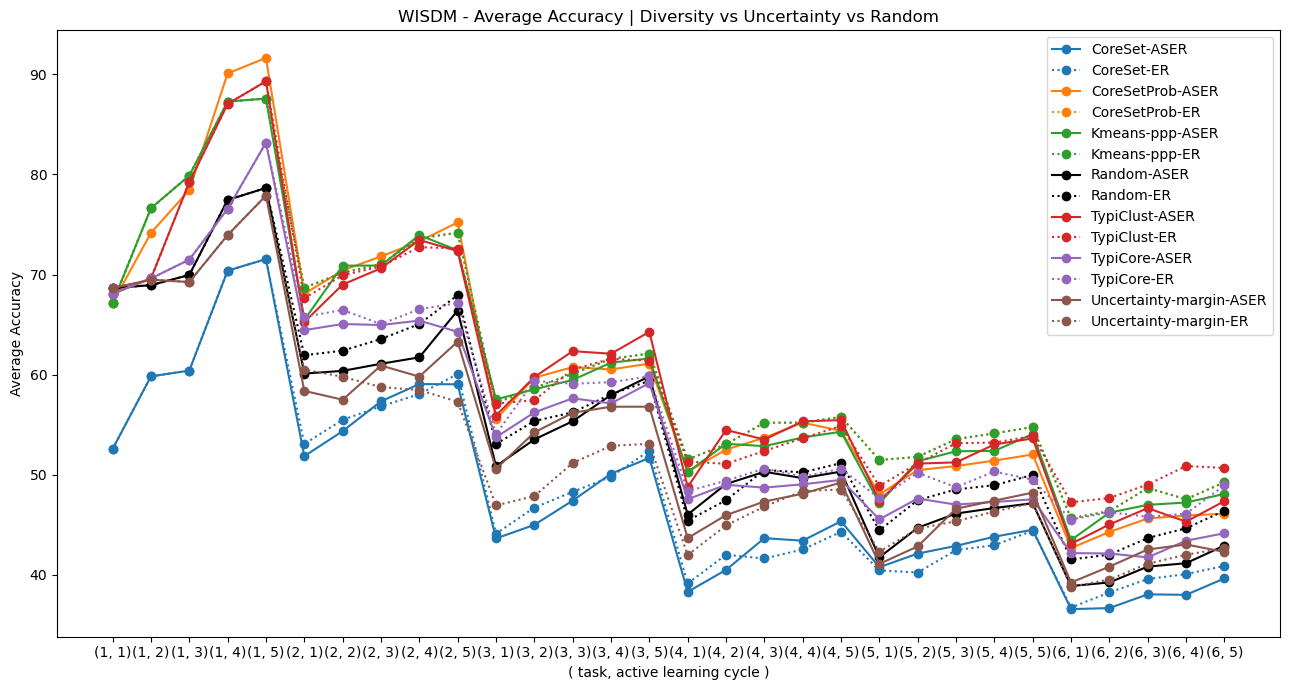

In [42]:
pu.plot_progress(
    df=uncert_aa,
    title=f"{DATASET} - Average Accuracy | Diversity vs Uncertainty vs Random",
    X_label="( task, active learning cycle )", 
    Y_label="Average Accuracy")

['AA_Random-ASER', 'LA_Random-ER']


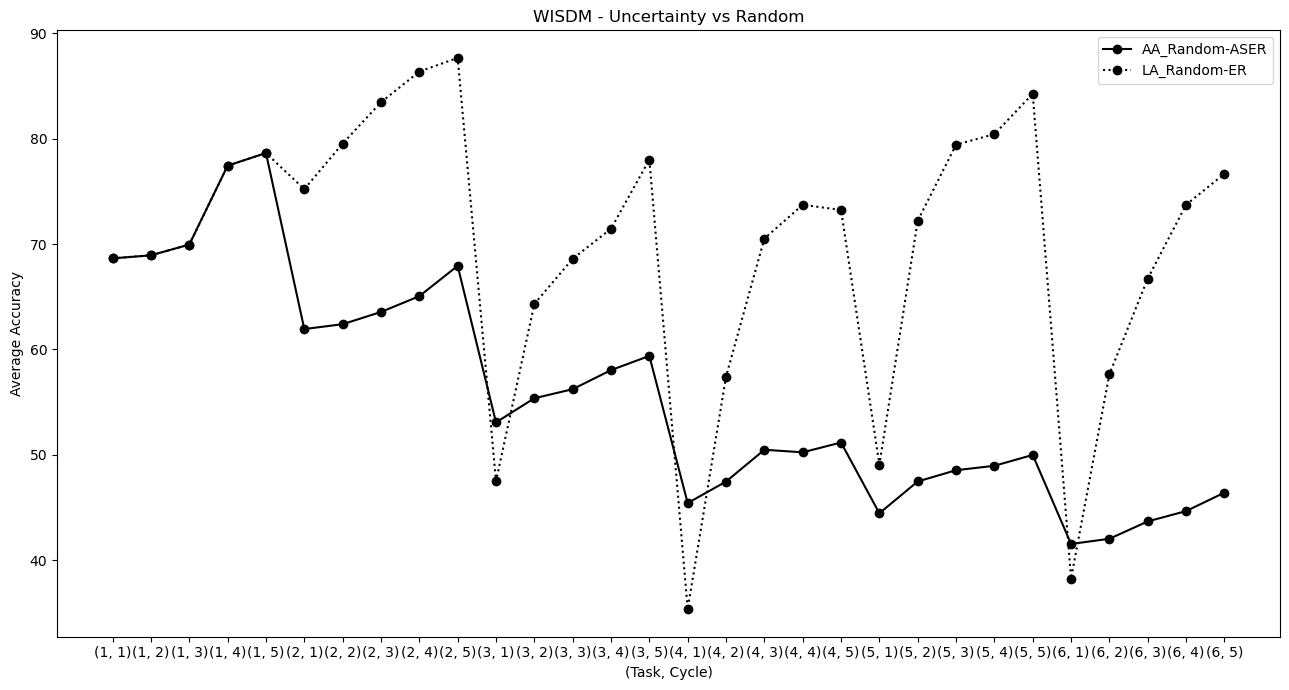

In [43]:
# Create dataframes with prefixes
aa_df = uncert_aa[['task','cycle', 'Random-ER']].copy()
la_df = uncert_la[['Random-ER']].copy()

aa_df.rename(columns={'Random-ER': 'AA_Random-ASER'}, inplace=True)
la_df.rename(columns={'Random-ER': 'LA_Random-ER'}, inplace=True)

df = pd.concat([aa_df, la_df], axis=1)

pu.plot_progress(
    df=df,
    title=f"{DATASET} - Uncertainty vs Random",
    X_label="(Task, Cycle)", 
    Y_label="Average Accuracy")

### Task-based

In [44]:
uncer_aa_task = pu.task_level_filter(uncert_aa) #.drop(['Uncertainty-entropy-ER', 'Uncertainty-entropy-ASER'], axis=1))
uncer_aa_task.style.apply(pu.highlight_max, axis=1).format(precision=2)

,task,cycle,index,Random-ER,Random-ASER,Uncertainty-margin-ER,Uncertainty-margin-ASER,TypiClust-ER,TypiClust-ASER,CoreSet-ER,CoreSet-ASER,CoreSetProb-ER,CoreSetProb-ASER,Kmeans-ppp-ASER,Kmeans-ppp-ER,TypiCore-ER,TypiCore-ASER
0,0,4,4,78.65,78.65,77.89,77.89,89.30,89.30,71.54,71.54,87.58,91.64,87.58,87.58,83.17,83.17
1,1,4,9,67.94,66.41,57.30,63.30,72.60,72.35,60.06,59.04,74.18,75.21,72.42,74.18,67.14,64.28
2,2,4,14,59.39,59.83,53.10,56.80,61.39,64.28,52.41,51.68,62.11,61.11,61.62,62.11,59.83,59.16
3,3,4,19,51.17,50.32,48.53,49.23,54.88,55.46,44.30,45.36,55.78,54.39,54.30,55.78,50.61,49.49
4,4,4,24,49.99,47.16,47.19,48.22,53.88,53.63,44.42,44.51,54.77,52.03,54.07,54.77,49.51,47.55
5,5,4,29,46.41,42.93,42.66,42.30,50.69,47.37,40.90,39.65,49.25,46.11,48.09,49.25,48.94,44.16


['Random-ER', 'Random-ASER', 'Uncertainty-margin-ER', 'Uncertainty-margin-ASER', 'TypiClust-ER', 'TypiClust-ASER', 'CoreSet-ER', 'CoreSet-ASER', 'CoreSetProb-ER', 'CoreSetProb-ASER', 'Kmeans-ppp-ASER', 'Kmeans-ppp-ER', 'TypiCore-ER', 'TypiCore-ASER']


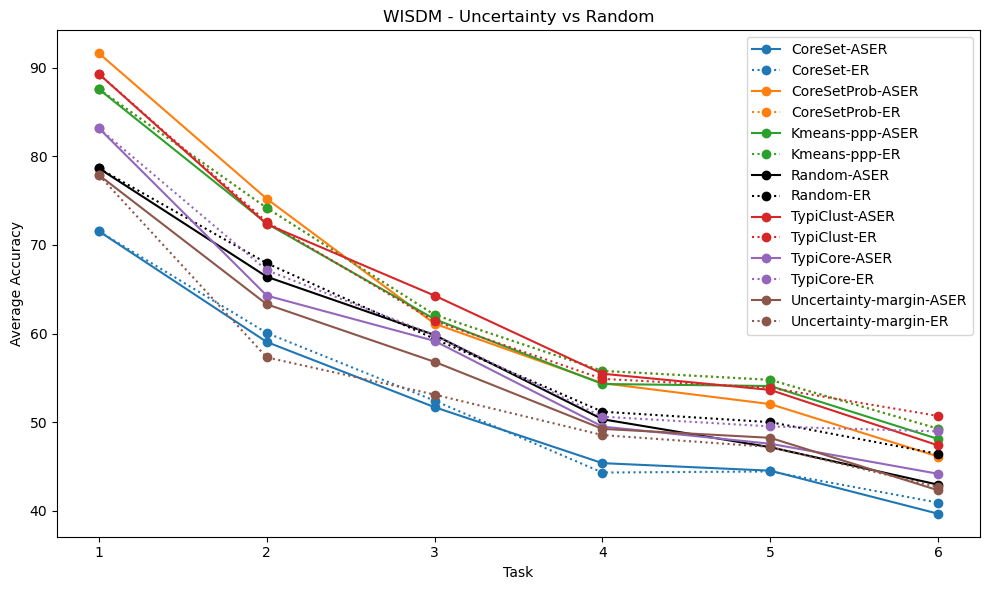

In [45]:
pu.plot_progress(
    df=uncer_aa_task,
    loc = 'upper right',
    figsize=(10, 6),
    title=f"{DATASET} - Uncertainty vs Random",
    X_label="Task", 
    Y_label="Average Accuracy")

In [46]:
uncer_la_task = pu.task_level_filter(uncert_la) #.drop(['Uncertainty-entropy-ER', 'Uncertainty-entropy-ASER'], axis=1))
uncer_la_task.style.apply(pu.highlight_max, axis=1).format(precision=2)

,task,cycle,index,Random-ER,Random-ASER,Uncertainty-margin-ER,Uncertainty-margin-ASER,TypiClust-ER,TypiClust-ASER,CoreSet-ER,CoreSet-ASER,CoreSetProb-ER,CoreSetProb-ASER,Kmeans-ppp-ASER,Kmeans-ppp-ER,TypiCore-ER,TypiCore-ASER
0,0,4,4,78.65,78.65,77.89,77.89,89.30,89.30,71.54,71.54,87.58,91.64,87.58,87.58,83.17,83.17
1,1,4,9,87.68,87.96,82.24,87.54,88.88,89.52,91.27,91.00,92.64,92.73,92.37,92.64,88.24,88.50
2,2,4,14,78.03,76.57,72.07,71.26,80.69,78.99,84.40,81.71,83.43,76.96,80.64,83.43,79.76,78.10
3,3,4,19,73.25,72.30,72.95,69.55,82.48,75.57,83.91,80.86,81.74,75.08,77.97,81.74,77.05,70.91
4,4,4,24,84.27,83.90,82.84,81.21,89.18,90.55,89.82,88.24,88.94,89.29,87.64,88.94,86.26,86.76
5,5,4,29,76.68,70.84,68.59,68.36,79.96,80.30,79.38,81.11,80.57,80.99,82.28,80.57,79.43,76.94


['Random-ER', 'Random-ASER', 'Uncertainty-margin-ER', 'Uncertainty-margin-ASER', 'TypiClust-ER', 'TypiClust-ASER', 'CoreSet-ER', 'CoreSet-ASER', 'CoreSetProb-ER', 'CoreSetProb-ASER', 'Kmeans-ppp-ASER', 'Kmeans-ppp-ER', 'TypiCore-ER', 'TypiCore-ASER']


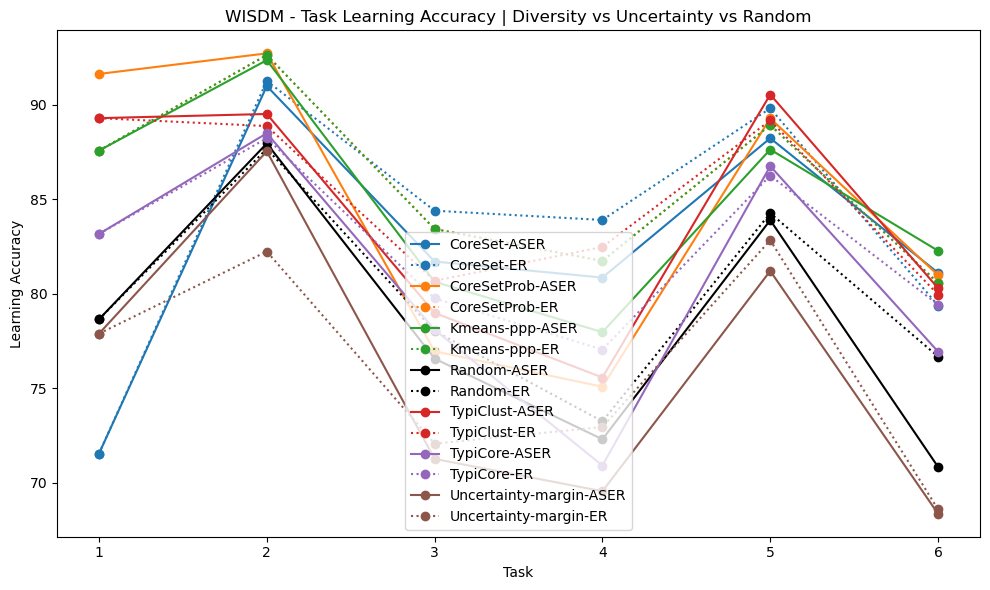

In [47]:
pu.plot_progress(
    df=uncer_la_task,
    loc = 'lower center',
    figsize=(10, 6),
    title=f"{DATASET} - Task Learning Accuracy | Diversity vs Uncertainty vs Random",
    X_label="Task", 
    Y_label="Learning Accuracy")

In [48]:
pu.add_aser_er_means(uncer_aa_task)
uncer_aa_task[['Random-ASER', 'Random-ER', 'ASER-mean', 'ER-mean']].style.apply(pu.highlight_max, axis=1).format(precision=2)

,Random-ASER,Random-ER,ASER-mean,ER-mean
0,78.65,78.65,83.52,82.84
1,66.41,67.94,67.77,67.58
2,59.83,59.39,59.11,58.49
3,50.32,51.17,51.37,51.65
4,47.16,49.99,50.00,50.76
5,42.93,46.41,44.61,46.95


In [49]:
pu.add_aser_er_means(uncer_la_task)
uncer_la_task[['Random-ASER', 'Random-ER', 'ASER-mean', 'ER-mean']].style.apply(pu.highlight_max, axis=1).format(precision=2)

,Random-ASER,Random-ER,ASER-mean,ER-mean
0,78.65,78.65,83.52,82.84
1,87.96,87.68,90.28,89.32
2,76.57,78.03,77.94,80.63
3,72.30,73.25,74.99,79.98
4,83.90,84.27,87.28,87.66
5,70.84,76.68,78.33,78.08


# Uncertainty Summary

In [50]:
acc_multiple_dataset_multiple_run = pu.get_multiple_al_methods_summary(filtered_files)
results_df = pu.ger_multiple_methods_summary_df(acc_multiple_dataset_multiple_run)
results_df.columns

Index(['Method', 'Avg End Acc', 'Avg End Acc error', 'Avg End Fgt',
       'Avg End Fgt error', 'Avg Cur Acc', 'Avg Cur Acc error', 'Avg Acc',
       'Avg Acc error'],
      dtype='object')

In [51]:
results_df = results_df[['Method', 'Avg End Acc', 'Avg End Acc error', 'Avg End Fgt',
       'Avg End Fgt error', 'Avg Cur Acc', 'Avg Cur Acc error']]

method_filter = ['TypiClust', 'CoreSet', 'Random', 'Kmeans-PPP']
results_df = results_df[results_df['Method'].apply(lambda x: any(mf in x for mf in method_filter))]

concat_df = pd.concat([results_df, tscil_results[DATASET]])
concat_df

,Method,Avg End Acc,Avg End Acc error,Avg End Fgt,Avg End Fgt error,Avg Cur Acc,Avg Cur Acc error
8,TypiClust_ER,50.69,3.97,41.27,4.71,85.08,7.63
9,TypiClust_ASER,47.37,3.64,44.00,9.44,84.04,9.97
10,TypiClustLimit_ER,50.42,2.04,40.77,7.65,84.39,5.78
11,TypiClustLimit_ASER,48.62,4.59,41.42,11.14,83.07,7.71
12,Random_ER,46.41,6.46,40.29,8.37,79.76,9.04
13,Random_ASER,42.93,5.01,42.88,5.87,78.37,8.04
16,CoreSet_ER,40.90,3.34,50.99,4.89,83.39,4.14
17,CoreSet_ASER,39.65,2.10,51.31,3.38,82.41,2.30
18,CoreSetProb_ER,49.25,5.27,43.88,8.14,85.82,6.83
19,CoreSetProb_ASER,46.11,3.42,46.01,7.13,84.45,5.46


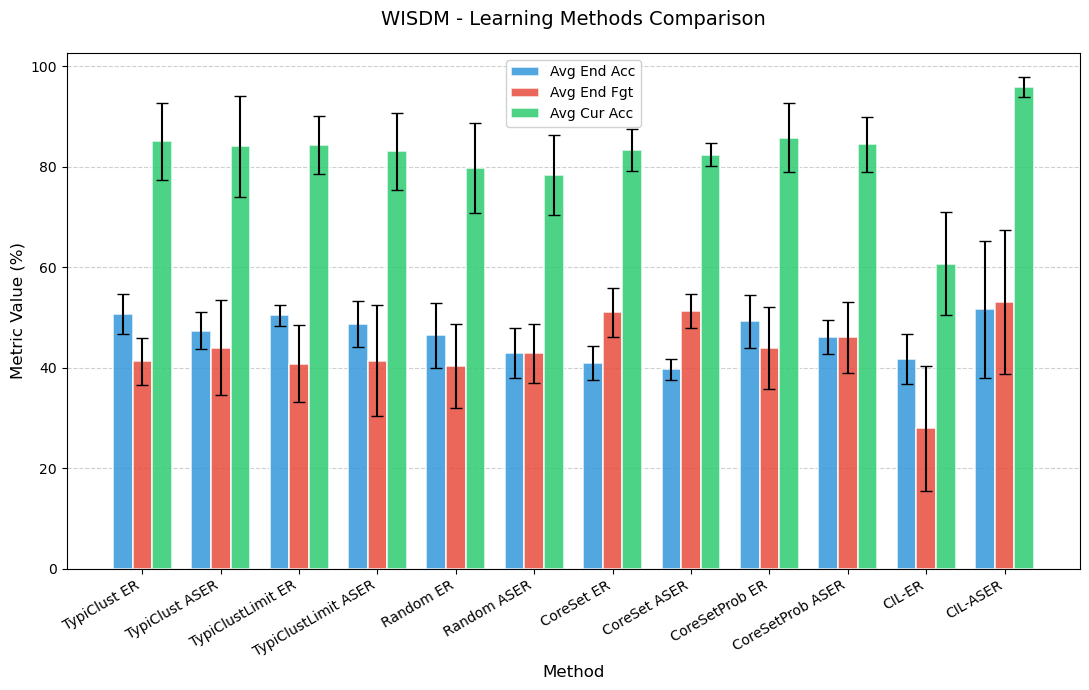

In [52]:
pu.plot_score_values(concat_df, DATASET, 'best')